In [51]:
import jax.numpy as jnp
import jax
import jaxdem as jd
jax.config.update("jax_enable_x64", True)
import numpy as np
import os
from bump_utils import create_dps_2d
import matplotlib.pyplot as plt
from anim import render
from jaxdem.forces.force_manager import ForceManager
from jaxdem.forces.deformable_particle import DeformableParticleContainer

def dp_component_force(state, system, dp, component_key: str):
    """
    component_key: one of {"E_bending", "E_edge", "E_content"}.
    Returns: (N, dim) force contribution from that DP energy term.
    """
    def component_energy(pos):
        _, aux = DeformableParticleContainer.compute_potential_energy(pos, state, system, dp)
        return aux[component_key]  # scalar

    pos = state.pos  # IMPORTANT: use the state's current ordering/coordinates
    return -jax.grad(component_energy)(pos)

root = '/home/mmccraw/dev/data/26-01-01/grant/dp-energy-conservation/dt-0.008999999999999998/'

In [50]:
state = jd.utils.load(os.path.join(root, 'state.h5'))
system = jd.utils.load(os.path.join(root, 'system.h5'))
dp = jd.utils.load(os.path.join(root, 'dp.h5'))
state_traj = jd.utils.load(os.path.join(root, 'state_traj.h5'))
system_traj = jd.utils.load(os.path.join(root, 'system_traj.h5'))
data = np.load(os.path.join(root, 'energies.npz'))
pe = data['pe']
ke = data['ke']

dp_force, dp_energy = dp.create_force_energy_functions(dp)
system.force_manager = ForceManager.create(
    state_shape=state.shape,
    gravity=None,
    force_functions=[(dp_force, dp_energy, False)],
)
system_traj.force_manager = ForceManager.create(
    state_shape=state_traj.shape,
    gravity=None,
    force_functions=[(dp_force, dp_energy, False)],
)

array([  771,  2442,  3182,  4959,  6341,  6619,  6812,  6899,  7164,
        7376,  9356,  9748, 10384, 10417, 10644])

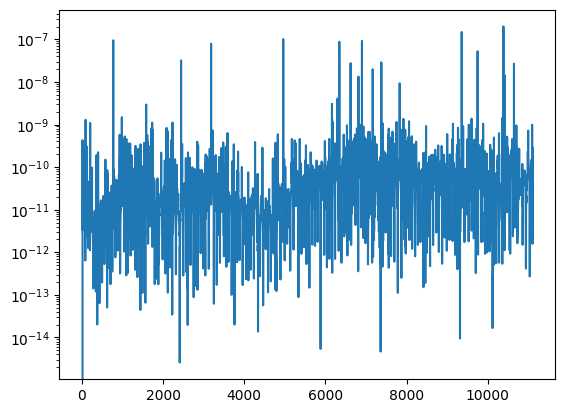

In [3]:
te = pe + ke
te_diff = abs(np.diff(te))
plt.plot(te_diff)
plt.yscale('log')
bad_indices = np.argwhere(te_diff > 1e-8).flatten()
bad_indices

In [6]:
render(state_traj, system_traj, 'frame_prior.png', 'deformable_ID', frame=bad_indices[0] - 10)

Running preprocessing on config.h5...
Metadata: 2 4.165224334730386 4.165224334730386
Running rendering -> frame_prior.png...
Headless Linux detected (DISPLAY unset). Using xvfb-run.
Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified
Saved rendering to frame_prior.png
Success.


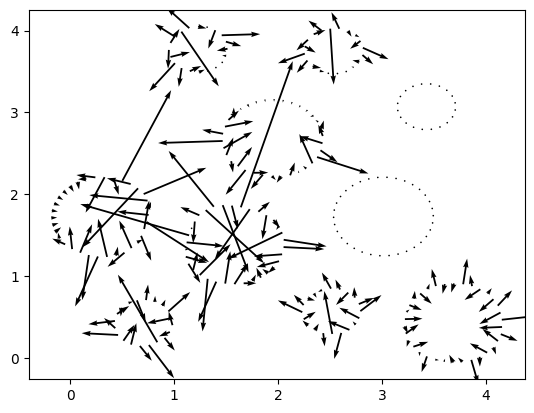

In [19]:
i = bad_indices[0] + -1

pos = state_traj.pos[i]
force = state_traj.force[i]
dpid = state_traj.deformable_ID[i]
plt.quiver(pos[:, 0], pos[:, 1], force[:, 0], force[:, 1])

In [68]:
R = jnp.array([[0.0, 1.0],
               [-1.0, 0.0]])

def segment_unit_normal(pos, i0, i1, eps=1e-12):
    e = pos[i1] - pos[i0]
    L = jnp.sqrt(jnp.dot(e, e) + eps)
    u = e / L
    n = R @ u
    return L, u, n

def bending_forces_one_hinge_2d(pos, a0, a1, b0, b1, eb, theta0, eps=1e-12):
    La, ua, na = segment_unit_normal(pos, a0, a1, eps)
    Lb, ub, nb = segment_unit_normal(pos, b0, b1, eps)

    c = jnp.clip(jnp.dot(na, nb), -1.0, 1.0)
    theta = jnp.arccos(c)
    s = jnp.sqrt(1.0 - c*c + eps)

    dE_dtheta = eb * (theta - theta0)
    dtheta_dna = -(nb - c * na) / s
    dtheta_dnb = -(na - c * nb) / s

    gna = dE_dtheta * dtheta_dna
    gnb = dE_dtheta * dtheta_dnb

    Pa = jnp.eye(2) - jnp.outer(ua, ua)
    Pb = jnp.eye(2) - jnp.outer(ub, ub)

    dE_dea = -(Pa @ (R @ gna)) / La
    dE_deb = -(Pb @ (R @ gnb)) / Lb

    Fa0, Fa1 = +dE_dea, -dE_dea
    Fb0, Fb1 = +dE_deb, -dE_deb
    return Fa0, Fa1, Fb0, Fb1, theta

def analytic_bending_force_frame(state_t, system_t, dp, eps=1e-12):
    pos = state_t.pos
    F = jnp.zeros_like(pos)

    elements = dp.elements              # (M,2) vertex IDs (actually indices for this GA DP)
    adj = dp.element_adjacency          # (A,2) element indices
    theta0 = dp.initial_bending         # (A,)
    body_id = dp.element_adjacency_ID   # (A,)
    eb_per_body = dp.eb                 # (K,)

    for a in range(adj.shape[0]):
        e0, e1 = int(adj[a,0]), int(adj[a,1])
        (a0, a1) = map(int, elements[e0])
        (b0, b1) = map(int, elements[e1])

        eb = float(eb_per_body[int(body_id[a])])
        Fa0, Fa1, Fb0, Fb1, _ = bending_forces_one_hinge_2d(pos, a0, a1, b0, b1, eb, float(theta0[a]), eps)

        F = F.at[a0].add(Fa0)
        F = F.at[a1].add(Fa1)
        F = F.at[b0].add(Fb0)
        F = F.at[b1].add(Fb1)

    return F

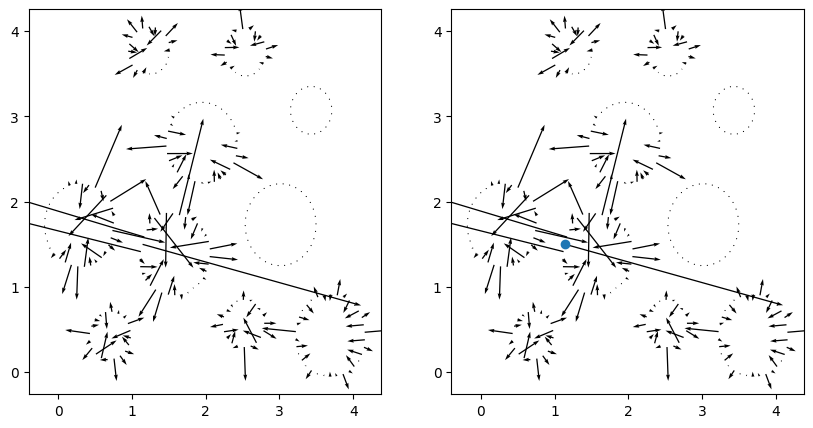

In [82]:
i = bad_indices[0] + 1

state_t = jax.tree.map(lambda x: x[i], state_traj)   # works if state_traj is stacked
system_t = jax.tree.map(lambda x: x[i], system_traj) # same idea; otherwise just system_traj[t]

F_eb = dp_component_force(state_t, system_t, dp, "E_bending")
F_el = dp_component_force(state_t, system_t, dp, "E_edge")
F_ec = dp_component_force(state_t, system_t, dp, "E_content")
F_bend_analytic = analytic_bending_force_frame(state_t, system_t, dp)

# fig, ax = plt.subplots(1, 3, figsize=(10, 5))
# ax[0].quiver(pos[:, 0], pos[:, 1], F_eb[:, 0], F_eb[:, 1])
# ax[1].quiver(pos[:, 0], pos[:, 1], F_el[:, 0], F_el[:, 1])
# ax[2].quiver(pos[:, 0], pos[:, 1], F_ec[:, 0], F_ec[:, 1])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].quiver(pos[:, 0], pos[:, 1], F_eb[:, 0], F_eb[:, 1])
ax[1].quiver(pos[:, 0], pos[:, 1], F_bend_analytic[:, 0], F_bend_analytic[:, 1])
bad = np.argmax(np.linalg.norm(F_eb - F_bend_analytic, axis=-1))
plt.scatter(*pos[bad].T)

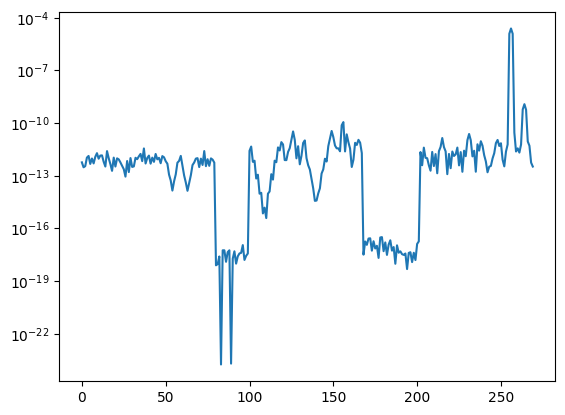

In [83]:
plt.plot(np.linalg.norm(F_eb - F_bend_analytic, axis=-1))
plt.yscale('log')

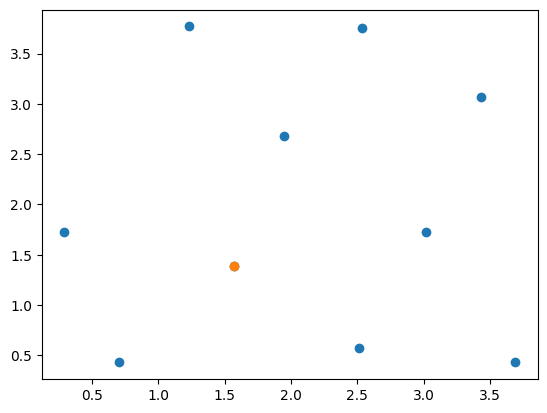

In [47]:
dppos = np.column_stack((np.bincount(dpid, weights=pos[:, 0]), np.bincount(dpid, weights=pos[:, 1]))) / np.bincount(dpid)[:, None]
plt.scatter(*dppos.T)

np.argmin(np.linalg.norm(np.abs(dppos - 1.5), axis=-1))

plt.scatter(*dppos[9].T)